### **Linear Regression**

##### Modules

In [11]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### Script for Linear Regression

In [12]:
class LinearRegression:
  def __init__(self,
               x_data: np.ndarray,
               y_data: np.ndarray,
               alpha: float = 0.001,
               iteration: int = 2000
               ) -> None:
    self.x = np.array(x_data, dtype=np.float64)
    self.y = np.array(y_data, dtype=np.float64)
    self.m = self.x.shape[0]

    if self.x.ndim == 1:
      self.x = self.x.reshape(-1, 1)

    self.n = self.x.shape[1]
    self.weight = np.zeros(self.n, dtype=np.float64)
    self.bias = 0.0
    self.alpha = alpha
    self.iteration = iteration

  def predict(self, data) -> np.ndarray:
    if data.ndim == 1:
      data = data.reshape(-1, 1)

    return np.dot(data, self.weight) + self.bias

  def cost_function(self) -> float:
    cost = 0.0

    for i in range(self.m):
      f_wb = self.predict(self.x[i])
      error = f_wb - self.y[i]

      cost += (error ** 2)

    cost /= (2 * self.m)
    return cost

  def compute_gradient(self) -> tuple[float, float]:
    dw, db = np.zeros(self.n, dtype=np.float64), 0.0
    dw = np.sum(np.dot((self.predict(self.x) - self.y), self.x))
    db += np.sum(self.predict(self.x) - self.y)

    dw /= self.m
    db /= self.m

    return dw, db

  def gradient_descent(self) -> None:
    for _ in range(self.iteration):
      dw, db = self.compute_gradient()
      self.weight -= self.alpha * dw
      self.bias -= self.alpha * db

#### What is Linear Regression?
Linear regression is a supervised learning algorithm used to model the relationship between a dependent variable and one or more independent variables by fitting a straight line (or hyperplane) that minimizes prediction error; mathematically, it predicts output using a linear equation where coefficients represent feature impact and are optimized by minimizing a cost function like Mean Squared Error through techniques such as gradient descent, making it highly interpretable and efficient for baseline modeling, though it assumes linearity, is sensitive to outliers, and struggles with complex non-linear patterns, which means it’s best positioned as a foundational model for understanding data relationships and benchmarking before deploying more advanced algorithms.

#### Terminology:
x: Input Features
y: Output Features / Target Features\
m: Number of Training Examples\
n: Number of Features in Training Example\
w: Weight\
b: Bias\
$\alpha$: alpha


#### Formula:
$$
f_{w,b}(x) = wx + b
$$


#### Cost Function:
In linear regression, the cost function quantifies how well the model’s predicted values align with actual data, and its primary role is to guide optimization; the most commonly used version is Mean Squared Error (MSE), which calculates the average of the squared differences between predicted and actual values, penalizing larger errors more heavily and ensuring a smooth optimization surface for algorithms like gradient descent, ultimately enabling the model to iteratively adjust its parameters (weights and bias) to minimize this error and converge toward the best-fit line.

$$
J(w, b) =  \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 + \frac{λ}{2m} \sum_{i=1}^{m}W_j^2
$$


#### Gradient Descent:
In linear regression, the gradient descent is an iterative optimizaton algorithm used to minimize a cost function by adjusting model parameters in the direction of the steepest descent of the function's gradient.\

repeat {
$$
w = w - \alpha\frac{d}{dw}J(w, b)
$$
$$
b = b - \alpha\frac{d}{db}J(w, b)
$$
}

$$
\frac{d}{dw} J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (f_{w, b}{x_i} - y_i)x_i + \frac{λ}{m}w_j
$$
$$
\frac{d}{db} J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (f_{w, b}{x_i} - y_i)
$$

##### Running the Model

Learned parameters: w = [2.2850764], b = 0.9139517071466096

For Test Input: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
Prediction: [ 0.91395171  3.1990281   5.4841045   7.7691809  10.05425729 12.33933369
 14.62441008 16.90948648 19.19456288 21.47963927]




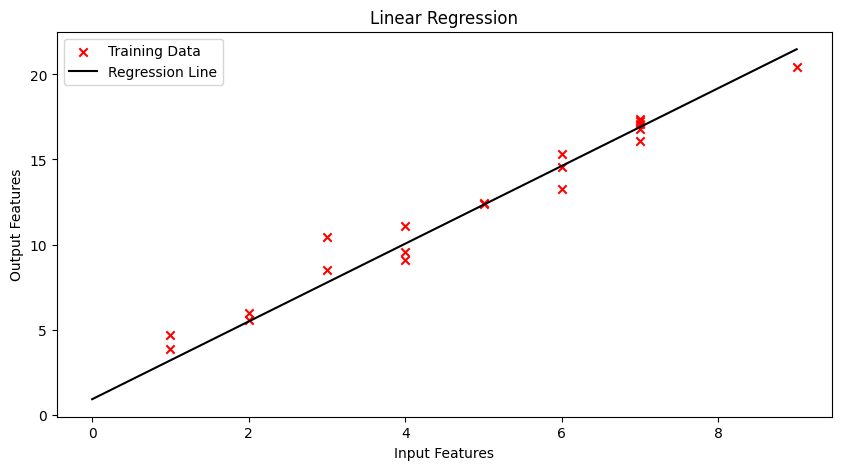

In [13]:
np.random.seed(42)

x_train = np.random.randint(0, 10, size=20)
y_train = 2 * x_train + 3 + np.random.randn(20)

model = LinearRegression(x_train, y_train)
model.gradient_descent()

print(f"Learned parameters: w = {model.weight}, b = {model.bias}\n")

x_test = np.linspace(0, 9, 10)
y_pred = model.predict(x_test)

print(f"For Test Input: {x_test}\nPrediction: {y_pred}\n\n")

plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, marker='x', color="red", label="Training Data")
plt.plot(x_test, y_pred, color="black", label="Regression Line")
plt.xlabel("Input Features")
plt.ylabel("Output Features")
plt.title("Linear Regression")
plt.legend()
plt.show()